OPTIMIZED DECISION TREE WITH 5-FOLD CV
Data Path: D:\2026 Work\Dr Hariharan Surendran\Paper 1 CS Glass Waste\Revision Work\Data\Data.csv
Results Directory: D:\2026 Work\Dr Hariharan Surendran\Paper 1 CS Glass Waste\Revision Work\Models\DecisionTree_20260720_095135

Dataset: 192 samples, 8 features
Target: Compressive strength (Mpa)

PREPROCESSING
After outlier removal: 192 samples

Train: 153, Test: 39

5-FOLD CROSS-VALIDATION

──────────────────────────────────────────────────
Testing: No Scaling
──────────────────────────────────────────────────
Fitting 5 folds for each of 50 candidates, totalling 250 fits
CV RMSE: 1.9584 ± 1.3286 | Test RMSE: 1.9961 | Test R²: 0.9277

──────────────────────────────────────────────────
Testing: StandardScaler
──────────────────────────────────────────────────
Fitting 5 folds for each of 50 candidates, totalling 250 fits
CV RMSE: 1.9062 ± 1.3299 | Test RMSE: 1.9961 | Test R²: 0.9277

──────────────────────────────────────────────────
Testing: RobustSc

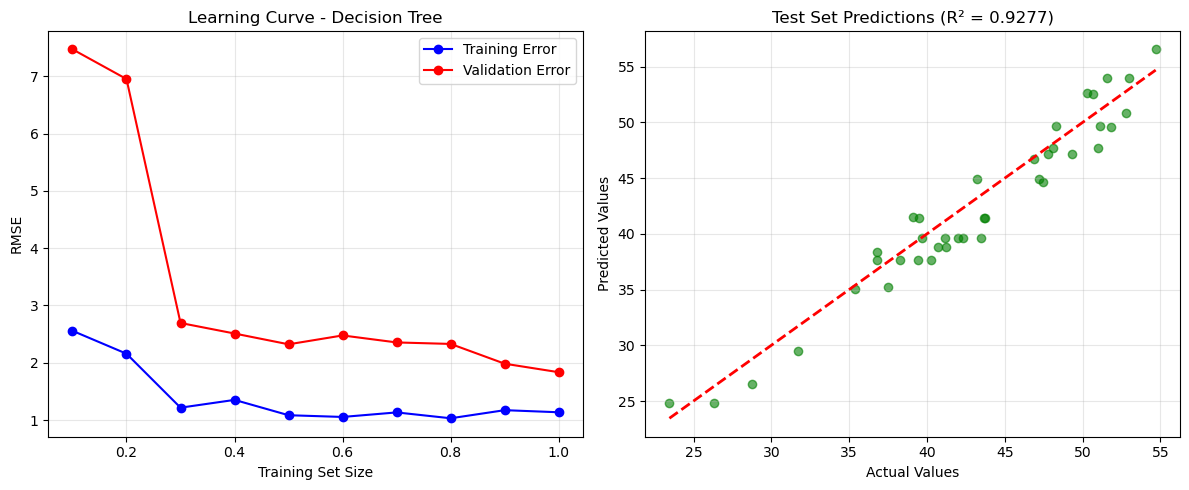


FINAL EVALUATION

------------------------------------------------------------
PERFORMANCE METRICS:
------------------------------------------------------------
Metric          Train           Test            Gap            
------------------------------------------------------------
R²              0.9873          0.9277          0.0596         
RMSE            0.9587          1.9961          1.0374         
MAE             0.7929          1.8134          1.0205         
MedAE           0.7500          1.9000          1.1500         
MAPE            1.9878          4.3237          2.3359         

------------------------------------------------------------
REGULARIZATION ASSESSMENT:
------------------------------------------------------------
🔴 POOR - Model is overfitting

Best Parameters:
  min_weight_fraction_leaf: 0.0
  min_samples_split: 5
  min_samples_leaf: 2
  min_impurity_decrease: 0.01
  max_leaf_nodes: 100
  max_features: None
  max_depth: 15
  ccp_alpha: 0.001

FEATURE I

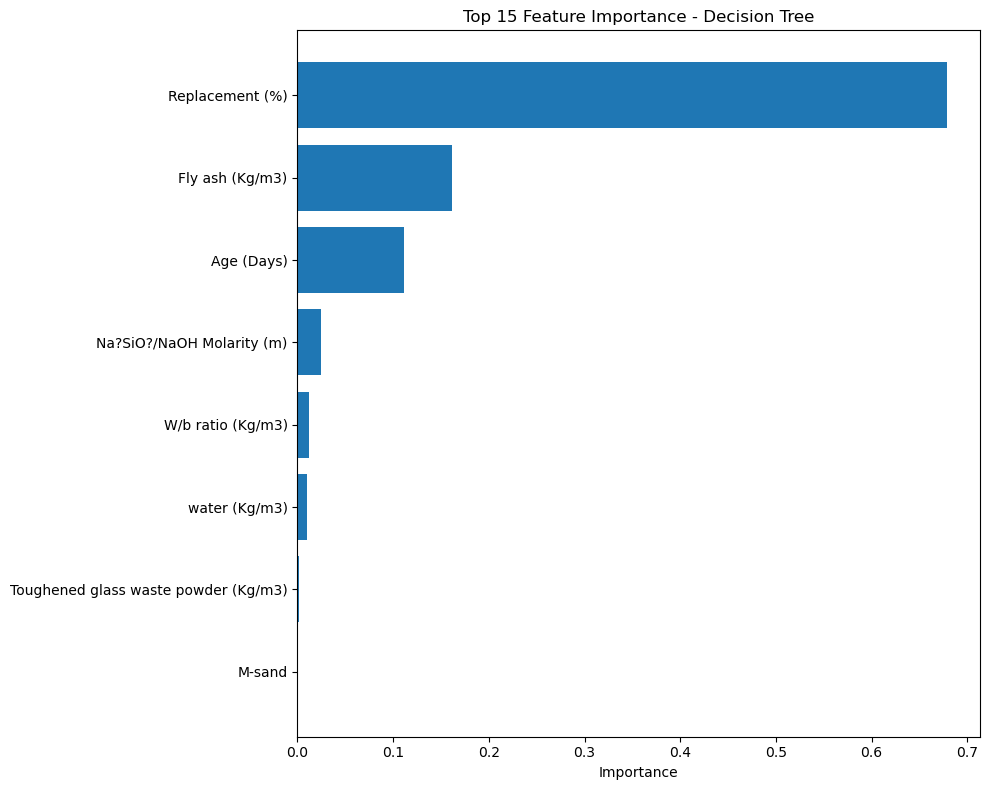


STUNNING BLACK BORDER SCATTER PLOTS
500 DPI • Publication-Ready • Bold Borders
✓ Data loaded — Train: 153 samples, Test: 39 samples
✓ Target range: [23.45, 57.50] MPa

════════════════════════════════════════════════════════════════════════════════
                     GENERATING STUNNING BLACK BORDER PLOTS                     
════════════════════════════════════════════════════════════════════════════════

▶ Creating Stunning 4-Plot Dashboard...


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


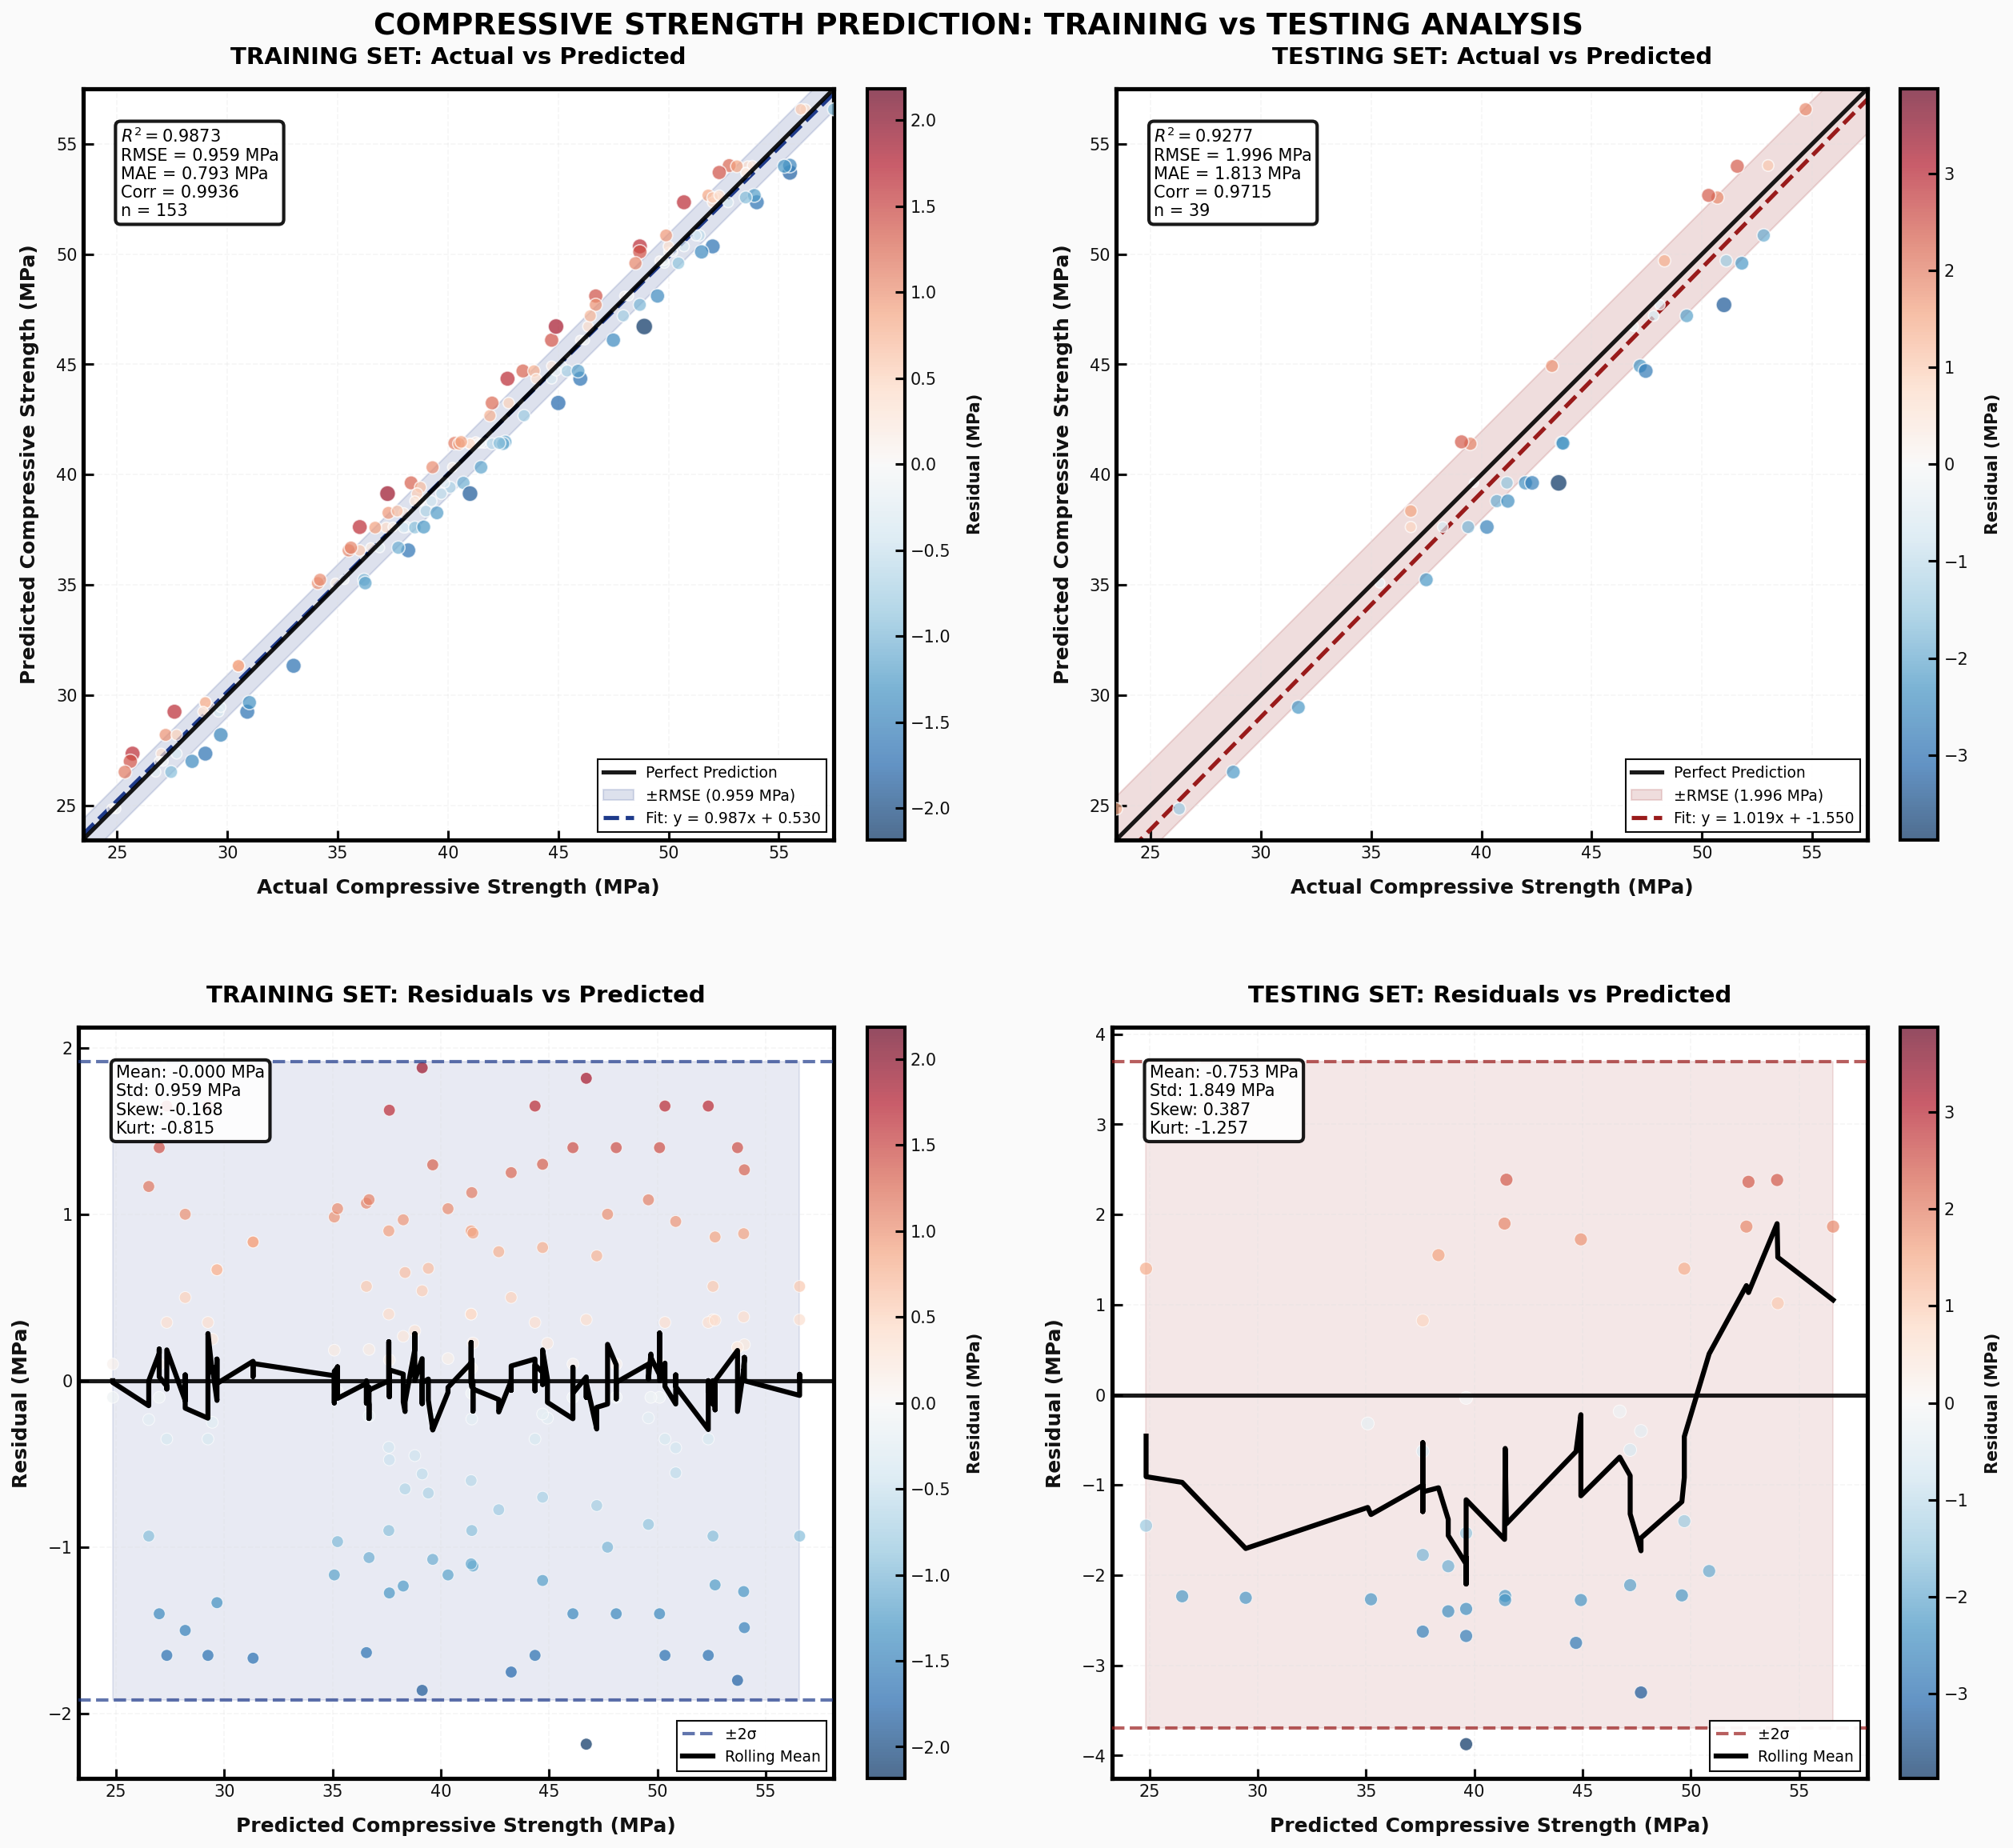

✓ Stunning 4-plot dashboard saved
▶ Creating Detailed Error Analysis...


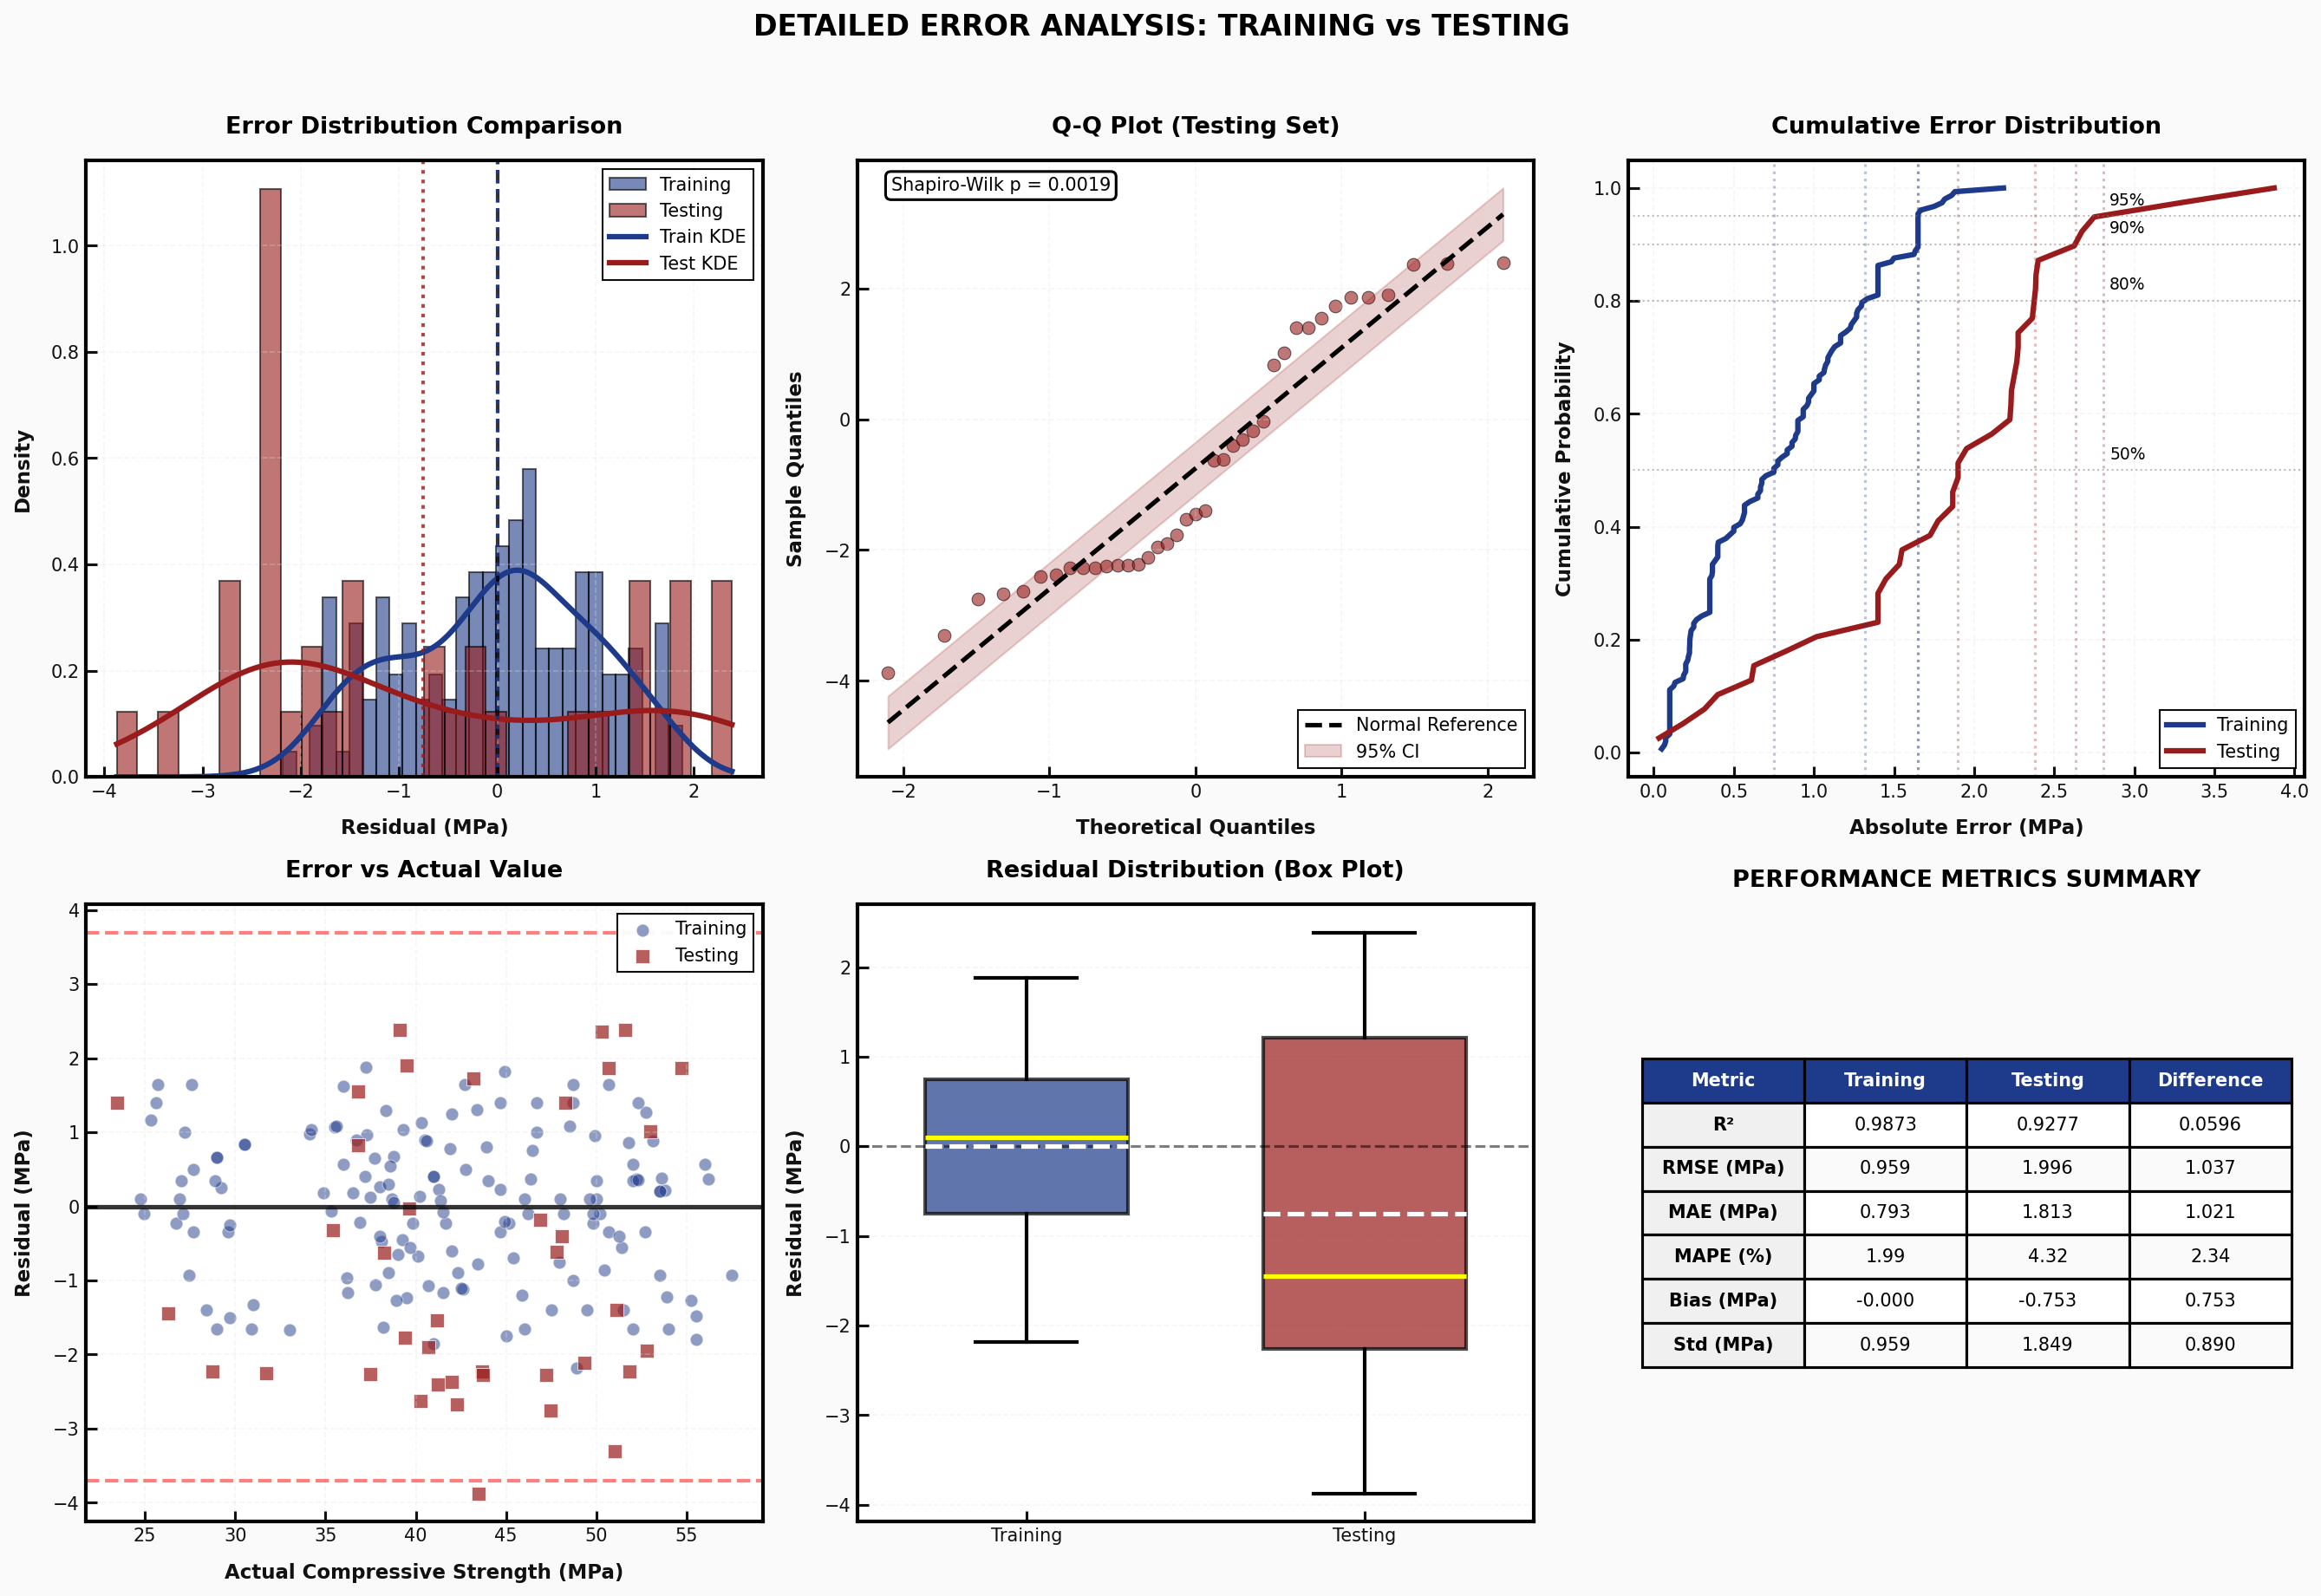

✓ Detailed error analysis saved

════════════════════════════════════════════════════════════════════════════════
                       ✓ ALL PLOTS GENERATED SUCCESSFULLY                       
════════════════════════════════════════════════════════════════════════════════

SAVING RESULTS

✅ All results saved to: D:\2026 Work\Dr Hariharan Surendran\Paper 1 CS Glass Waste\Revision Work\Models\DecisionTree_20260720_095135/

PROGRAM COMPLETED SUCCESSFULLY!

Files saved:
  • D:\2026 Work\Dr Hariharan Surendran\Paper 1 CS Glass Waste\Revision Work\Models\DecisionTree_20260720_095135/
    - cv_results.csv (5-Fold CV Results)
    - best_model_decisiontree.pkl (Trained Model)
    - best_params.csv (Best Parameters)
    - metrics.csv (Performance Metrics)
    - feature_importance.csv
    - train_predictions.csv / test_predictions.csv
    - learning_curve.png
    - feature_importance.png
    - stunning_4plot_dashboard.png/pdf (Main 4-Plot Dashboard)
    - error_analysis_detailed.png/pdf (Detai

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
import difflib
import warnings
import os
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from scipy.stats import gaussian_kde
import joblib
warnings.filterwarnings('ignore')

# Set paths
DATA_PATH = r'D:\2026 Work\Dr Hariharan Surendran\Paper 1 CS Glass Waste\Revision Work\Data\Data.csv'
RESULTS_BASE = r'D:\2026 Work\Dr Hariharan Surendran\Paper 1 CS Glass Waste\Revision Work\Models'

# Create results directory with timestamp
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = os.path.join(RESULTS_BASE, f"DecisionTree_{timestamp}")
os.makedirs(results_dir, exist_ok=True)

print("="*80)
print("OPTIMIZED DECISION TREE WITH 5-FOLD CV")
print("="*80)
print(f"Data Path: {DATA_PATH}")
print(f"Results Directory: {results_dir}")

# Load data
df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')
df.columns = df.columns.str.strip()

# Find target
target_col = 'Compressive strength (Mpa)'
if target_col not in df.columns:
    matches = difflib.get_close_matches('Compressive strength', df.columns, n=3, cutoff=0.6)
    target_col = matches[0] if matches else None
    
if target_col is None:
    print("Target column not found!")
    print("Available columns:", df.columns.tolist())
    exit()

X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\nDataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Target: {target_col}")

# Preprocessing
print("\n" + "="*80)
print("PREPROCESSING")
print("="*80)

# Handle missing values
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna('missing').astype(str)
    else:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        X[col] = X[col].fillna(X[col].median())

# Remove extreme outliers
z_scores = np.abs(stats.zscore(y))
X = X[z_scores < 3]
y = y[z_scores < 3]
print(f"After outlier removal: {len(X)} samples")

# Handle categorical features (one-hot encoding)
categorical_columns = []
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype.name == 'category':
        categorical_columns.append(col)

if categorical_columns:
    print(f"Categorical features: {categorical_columns}")
    # One-hot encode categorical variables
    X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)
    print(f"After one-hot encoding: {X.shape[1]} features")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

# ====================================================================
# 5-FOLD CROSS-VALIDATION WITH OPTIMAL PARAMETERS
# ====================================================================
print("\n" + "="*80)
print("5-FOLD CROSS-VALIDATION")
print("="*80)

# Define parameter grid for Decision Tree
param_grid = {
    'max_depth': [None, 5, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'min_weight_fraction_leaf': [0.0, 0.1, 0.2],
    'max_leaf_nodes': [None, 10, 20, 50, 100],
    'min_impurity_decrease': [0.0, 0.01, 0.05, 0.1],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1]
}

# Initialize results storage
cv_results = []
best_score = np.inf
best_model = None
best_params = None

# Try different scalers
scalers = {
    'No Scaling': None,
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
}

for scaler_name, scaler in scalers.items():
    print(f"\n{'─'*50}")
    print(f"Testing: {scaler_name}")
    print(f"{'─'*50}")
    
    # Apply scaling (Decision Tree doesn't need scaling, but we'll keep for consistency)
    if scaler is not None:
        numeric_cols = X_train.select_dtypes(include=[np.number]).columns
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
        X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
    else:
        X_train_scaled = X_train
        X_test_scaled = X_test
    
    # Initialize Decision Tree model
    dt_model = DecisionTreeRegressor(random_state=42)
    
    # Use RandomizedSearchCV for efficiency
    dt_random = RandomizedSearchCV(
        estimator=dt_model,
        param_distributions=param_grid,
        n_iter=50,  # Number of parameter combinations to try
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        scoring='neg_root_mean_squared_error'
    )
    
    # Fit the random search model
    dt_random.fit(X_train_scaled, y_train)
    
    # Get best model and parameters
    best_model_cv = dt_random.best_estimator_
    best_params_cv = dt_random.best_params_
    cv_rmse = -dt_random.best_score_
    cv_std = np.std(-dt_random.cv_results_['mean_test_score'])  # Approximate
    
    # Test performance
    test_pred = best_model_cv.predict(X_test_scaled)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)
    
    # Store results
    result = {
        'scaler': scaler_name,
        'params': best_params_cv,
        'cv_rmse': cv_rmse,
        'cv_std': cv_std,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'model': best_model_cv
    }
    cv_results.append(result)
    
    # Track best model (based on CV RMSE)
    if cv_rmse < best_score:
        best_score = cv_rmse
        best_model = best_model_cv
        best_params = best_params_cv
        best_scaler_name = scaler_name
        best_X_test_scaled = X_test_scaled
        best_scaler = scaler
    
    print(f"CV RMSE: {cv_rmse:.4f} ± {cv_std:.4f} | Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")

# ====================================================================
# 5-FOLD CROSS-VALIDATION TABLE
# ====================================================================
print("\n" + "="*80)
print("5-FOLD CROSS-VALIDATION RESULTS TABLE")
print("="*80)

# Create CV results table
cv_table_data = []
for i, result in enumerate(cv_results):
    cv_table_data.append([
        result['scaler'],
        f"{result['cv_rmse']:.4f} ± {result['cv_std']:.4f}",
        f"{result['test_rmse']:.4f}",
        f"{result['test_r2']:.4f}"
    ])

# Print table
print("\n")
print("┌─────────────────┬─────────────────────┬────────────┬────────┐")
print("│ Scaler          │ CV RMSE (5-Fold)    │ Test RMSE  │ Test R²│")
print("├─────────────────┼─────────────────────┼────────────┼────────┤")
for row in cv_table_data:
    print(f"│ {row[0]:<15} │ {row[1]:<19} │ {row[2]:<10} │ {row[3]:<6} │")
print("└─────────────────┴─────────────────────┴────────────┴────────┘")

# Save CV results to CSV
cv_df = pd.DataFrame([
    {
        'Scaler': r['scaler'],
        'CV_RMSE': r['cv_rmse'],
        'CV_Std': r['cv_std'],
        'Test_RMSE': r['test_rmse'],
        'Test_R2': r['test_r2']
    } for r in cv_results
])
cv_df.to_csv(os.path.join(results_dir, "cv_results.csv"), index=False)

# ====================================================================
# LEARNING CURVE
# ====================================================================
print("\n" + "="*80)
print("GENERATING LEARNING CURVE")
print("="*80)

# Get best model predictions
if best_scaler_name != 'No Scaling' and best_scaler is not None:
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns
    X_train_final = X_train.copy()
    X_test_final = X_test.copy()
    X_train_final[numeric_cols] = best_scaler.transform(X_train[numeric_cols])
    X_test_final[numeric_cols] = best_scaler.transform(X_test[numeric_cols])
else:
    X_train_final = X_train
    X_test_final = X_test

train_pred = best_model.predict(X_train_final)
test_pred = best_model.predict(X_test_final)

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print(f"\nBest Model ({best_scaler_name}):")
print(f"Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")
print(f"Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
print(f"RMSE Gap: {test_rmse - train_rmse:.4f}")

# Generate learning curve
train_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
train_scores = []
cv_scores = []

for size in train_sizes:
    n_samples = int(len(X_train) * size)
    X_subset = X_train.iloc[:n_samples]
    y_subset = y_train.iloc[:n_samples]
    
    # Apply scaling if needed
    if best_scaler_name != 'No Scaling' and best_scaler is not None:
        numeric_cols = X_subset.select_dtypes(include=[np.number]).columns
        X_subset_scaled = X_subset.copy()
        X_subset_scaled[numeric_cols] = RobustScaler().fit_transform(X_subset[numeric_cols])
    else:
        X_subset_scaled = X_subset
    
    # Create Decision Tree model with best parameters
    model = DecisionTreeRegressor(**best_params, random_state=42)
    
    # Split for validation
    X_tr, X_val, y_tr, y_val = train_test_split(X_subset_scaled, y_subset, test_size=0.2, random_state=42)
    model.fit(X_tr, y_tr)
    
    # Evaluate
    train_pred_sub = model.predict(X_tr)
    cv_pred = model.predict(X_val)
    
    train_scores.append(np.sqrt(mean_squared_error(y_tr, train_pred_sub)))
    cv_scores.append(np.sqrt(mean_squared_error(y_val, cv_pred)))

# Plot learning curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_sizes, train_scores, 'o-', label='Training Error', color='blue')
plt.plot(train_sizes, cv_scores, 'o-', label='Validation Error', color='red')
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title('Learning Curve - Decision Tree')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Test Set Predictions (R² = {test_r2:.4f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "learning_curve.png"), dpi=300)
plt.show()

# ====================================================================
# FINAL EVALUATION
# ====================================================================
print("\n" + "="*80)
print("FINAL EVALUATION")
print("="*80)

# Comprehensive metrics
def all_metrics(y_true, y_pred):
    return {
        'R²': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MedAE': np.median(np.abs(y_true - y_pred)),
        'MAPE': np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    }

train_metrics = all_metrics(y_train, train_pred)
test_metrics = all_metrics(y_test, test_pred)

print("\n" + "-" * 60)
print("PERFORMANCE METRICS:")
print("-" * 60)
print(f"{'Metric':<15} {'Train':<15} {'Test':<15} {'Gap':<15}")
print("-" * 60)

for metric in train_metrics.keys():
    train_val = train_metrics[metric]
    test_val = test_metrics[metric]
    if metric == 'R²':
        gap = train_val - test_val
    else:
        gap = test_val - train_val
    print(f"{metric:<15} {train_val:<15.4f} {test_val:<15.4f} {gap:<15.4f}")

# Regularization assessment
print("\n" + "-" * 60)
print("REGULARIZATION ASSESSMENT:")
print("-" * 60)

rmse_gap = test_metrics['RMSE'] - train_metrics['RMSE']
r2_gap = train_metrics['R²'] - test_metrics['R²']

if rmse_gap < 0.2:
    print("✅ EXCELLENT - Model is well-regularized")
elif rmse_gap < 0.4:
    print("🟡 GOOD - Acceptable regularization")
elif rmse_gap < 0.6:
    print("🟠 MODERATE - Consider increasing regularization")
else:
    print("🔴 POOR - Model is overfitting")

print(f"\nBest Parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# ====================================================================
# FEATURE IMPORTANCE
# ====================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Feature importance
feature_importance = best_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance - Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "feature_importance.png"), dpi=300)
plt.show()

# ====================================================================
# STUNNING BLACK BORDER SCATTER PLOTS - COMPRESSIVE STRENGTH
# ====================================================================
print("\n" + "="*80)
print("STUNNING BLACK BORDER SCATTER PLOTS")
print("500 DPI • Publication-Ready • Bold Borders")
print("="*80)

# ====================================================================
# ELEGANT PALETTE WITH DARK BORDERS
# ====================================================================
PALETTE = {
    'bg': '#FAFAFA',              # Light background
    'surface': '#FFFFFF',          # White surface
    'surface2': '#F5F5F5',         # Light gray for alternating rows
    'border': '#000000',           # BLACK BORDERS (bold)
    'grid': '#E0E0E0',             # Light grid
    'train_core': '#1E3A8A',       # Deep blue for training
    'train_light': '#3B82F6',       # Bright blue
    'test_core': '#991B1B',         # Deep red for testing
    'test_light': '#EF4444',         # Bright red
    'perfect': '#DC2626',           # Red perfect line
    'text_hi': '#111111',           # Dark text
    'text_mid': '#4B5563',           # Medium text
    'accent': '#059669',             # Green accent
    'warning': '#D97706',            # Orange warning
}

# Set global style with BLACK BORDERS
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'figure.facecolor': PALETTE['bg'],
    'axes.facecolor': PALETTE['surface'],
    'axes.edgecolor': PALETTE['border'],     # BLACK border
    'axes.linewidth': 2.0,                    # BOLD border
    'axes.labelcolor': PALETTE['text_hi'],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelpad': 10,
    'axes.titlepad': 15,
    'xtick.color': PALETTE['text_hi'],
    'ytick.color': PALETTE['text_hi'],
    'xtick.major.size': 6,
    'xtick.major.width': 1.5,
    'ytick.major.size': 6,
    'ytick.major.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.frameon': True,
    'legend.facecolor': PALETTE['surface'],
    'legend.edgecolor': PALETTE['border'],
    'legend.fancybox': False,
    'legend.framealpha': 0.95,
    'grid.color': PALETTE['grid'],
    'grid.linewidth': 0.8,
    'grid.alpha': 0.7,
    'figure.dpi': 150,
    'savefig.dpi': 500,
    'savefig.facecolor': PALETTE['bg'],
    'savefig.edgecolor': PALETTE['border'],
    'savefig.bbox': 'tight',
})

# ====================================================================
# DATA PREPARATION FOR PLOTS
# ====================================================================
def prepare_plot_data():
    """Prepare data for plotting"""
    global y_train_np, train_pred_np, y_test_np, test_pred_np
    
    # Convert to numpy arrays
    y_train_np = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
    train_pred_np = train_pred if hasattr(train_pred, 'values') else np.array(train_pred)
    y_test_np = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
    test_pred_np = test_pred if hasattr(test_pred, 'values') else np.array(test_pred)
    
    print(f"✓ Data loaded — Train: {len(y_train_np)} samples, Test: {len(y_test_np)} samples")
    print(f"✓ Target range: [{min(y_train_np.min(), y_test_np.min()):.2f}, {max(y_train_np.max(), y_test_np.max()):.2f}] MPa")
    
    return y_train_np, train_pred_np, y_test_np, test_pred_np

y_train_np, train_pred_np, y_test_np, test_pred_np = prepare_plot_data()

# ====================================================================
# METRICS COMPUTATION FOR PLOTS
# ====================================================================
def compute_metrics(actual, predicted, name=""):
    """Compute comprehensive metrics"""
    res = predicted - actual
    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs(res / np.where(actual != 0, actual, 1e-10))) * 100
    bias = np.mean(res)
    std = np.std(res)
    
    # Calculate correlation
    corr = np.corrcoef(actual, predicted)[0, 1]
    
    # Calculate skewness and kurtosis
    skew = stats.skew(res)
    kurt = stats.kurtosis(res)
    
    return {
        'name': name,
        'n': len(actual),
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'bias': bias,
        'std': std,
        'corr': corr,
        'skew': skew,
        'kurt': kurt,
        'res': res,
        'actual': actual,
        'predicted': predicted
    }

train_m = compute_metrics(y_train_np, train_pred_np, "TRAINING")
test_m = compute_metrics(y_test_np, test_pred_np, "TESTING")

# ====================================================================
# FIGURE 1: STUNNING 4-PLOT DASHBOARD
# ====================================================================
def create_stunning_4plot():
    """Create 4 stunning plots with black borders"""
    
    # Create figure with GridSpec for perfect layout
    fig = plt.figure(figsize=(20, 16))
    fig.patch.set_facecolor(PALETTE['bg'])
    
    # Create grid: 2x2 with proper spacing
    gs = gridspec.GridSpec(2, 2, figure=fig, 
                           hspace=0.25, wspace=0.25,
                           height_ratios=[1, 1],
                           width_ratios=[1, 1])
    
    # ====================================================================
    # PLOT 1: TRAINING SET SCATTER (TOP LEFT)
    # ====================================================================
    ax1 = fig.add_subplot(gs[0, 0])
    
    # Calculate metrics
    train_corr = train_m['corr']
    
    # Create scatter with size based on residual
    train_res = train_m['res']
    train_abs_res = np.abs(train_res)
    sizes = 30 + 70 * (train_abs_res / (train_abs_res.max() + 1e-9))
    
    # Scatter plot - color by signed residual
    scatter1 = ax1.scatter(train_m['actual'], train_m['predicted'], 
                          c=train_res, cmap='RdBu_r',
                          s=sizes, alpha=0.7,
                          edgecolors='white', linewidth=0.8,
                          vmin=-train_abs_res.max(), vmax=train_abs_res.max(),
                          zorder=3)
    
    # Perfect prediction line
    min_val = min(train_m['actual'].min(), train_m['predicted'].min(),
                  test_m['actual'].min(), test_m['predicted'].min())
    max_val = max(train_m['actual'].max(), train_m['predicted'].max(),
                  test_m['actual'].max(), test_m['predicted'].max())
    line = np.linspace(min_val, max_val, 100)
    ax1.plot(line, line, '-', color='black', linewidth=2.5, 
            label='Perfect Prediction', alpha=0.9, zorder=4)
    
    # ±RMSE bands
    ax1.fill_between(line, line - train_m['rmse'], line + train_m['rmse'],
                     color=PALETTE['train_core'], alpha=0.15, zorder=1,
                     label=f'±RMSE ({train_m["rmse"]:.3f} MPa)')
    
    # Add equation and R²
    z = np.polyfit(train_m['actual'], train_m['predicted'], 1)
    p = np.poly1d(z)
    ax1.plot(line, p(line), '--', color=PALETTE['train_core'], 
            linewidth=2.5, label=f'Fit: y = {z[0]:.3f}x + {z[1]:.3f}', zorder=2)
    
    # Customize
    ax1.set_xlabel('Actual Compressive Strength (MPa)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Predicted Compressive Strength (MPa)', fontsize=12, fontweight='bold')
    ax1.set_title('TRAINING SET: Actual vs Predicted', fontsize=14, fontweight='bold', pad=15)
    
    # Add text box with metrics
    textstr = (f'$R^2 = {train_m["r2"]:.4f}$\n'
               f'RMSE = {train_m["rmse"]:.3f} MPa\n'
               f'MAE = {train_m["mae"]:.3f} MPa\n'
               f'Corr = {train_corr:.4f}\n'
               f'n = {train_m["n"]}')
    
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, 
                edgecolor='black', linewidth=2)
    ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
            verticalalignment='top', bbox=props, zorder=5)
    
    # Legend
    ax1.legend(loc='lower right', frameon=True, edgecolor='black', fancybox=False, fontsize=9)
    
    # Grid
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)
    ax1.set_aspect('equal', adjustable='box')
    
    # Ensure black border is prominent
    for spine in ax1.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2.5)
    
    # ====================================================================
    # PLOT 2: TESTING SET SCATTER (TOP RIGHT)
    # ====================================================================
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Calculate metrics
    test_corr = test_m['corr']
    
    # Create scatter with size based on residual
    test_res = test_m['res']
    test_abs_res = np.abs(test_res)
    sizes = 30 + 70 * (test_abs_res / (test_abs_res.max() + 1e-9))
    
    # Scatter plot - color by signed residual
    scatter2 = ax2.scatter(test_m['actual'], test_m['predicted'], 
                          c=test_res, cmap='RdBu_r',
                          s=sizes, alpha=0.7,
                          edgecolors='white', linewidth=0.8,
                          vmin=-test_abs_res.max(), vmax=test_abs_res.max(),
                          zorder=3)
    
    # Perfect prediction line
    ax2.plot(line, line, '-', color='black', linewidth=2.5, 
            label='Perfect Prediction', alpha=0.9, zorder=4)
    
    # ±RMSE bands
    ax2.fill_between(line, line - test_m['rmse'], line + test_m['rmse'],
                     color=PALETTE['test_core'], alpha=0.15, zorder=1,
                     label=f'±RMSE ({test_m["rmse"]:.3f} MPa)')
    
    # Add equation and R²
    z = np.polyfit(test_m['actual'], test_m['predicted'], 1)
    p = np.poly1d(z)
    ax2.plot(line, p(line), '--', color=PALETTE['test_core'], 
            linewidth=2.5, label=f'Fit: y = {z[0]:.3f}x + {z[1]:.3f}', zorder=2)
    
    # Customize
    ax2.set_xlabel('Actual Compressive Strength (MPa)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Predicted Compressive Strength (MPa)', fontsize=12, fontweight='bold')
    ax2.set_title('TESTING SET: Actual vs Predicted', fontsize=14, fontweight='bold', pad=15)
    
    # Add text box with metrics
    textstr = (f'$R^2 = {test_m["r2"]:.4f}$\n'
               f'RMSE = {test_m["rmse"]:.3f} MPa\n'
               f'MAE = {test_m["mae"]:.3f} MPa\n'
               f'Corr = {test_corr:.4f}\n'
               f'n = {test_m["n"]}')
    
    ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=10,
            verticalalignment='top', bbox=props, zorder=5)
    
    # Legend
    ax2.legend(loc='lower right', frameon=True, edgecolor='black', fancybox=False, fontsize=9)
    
    # Grid
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)
    ax2.set_aspect('equal', adjustable='box')
    
    # Ensure black border is prominent
    for spine in ax2.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2.5)
    
    # Add colorbars
    cbar1 = plt.colorbar(scatter1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.set_label('Residual (MPa)', fontsize=10, fontweight='bold')
    cbar1.ax.yaxis.set_tick_params(color='black')
    cbar1.outline.set_edgecolor('black')
    cbar1.outline.set_linewidth(2)
    
    cbar2 = plt.colorbar(scatter2, ax=ax2, fraction=0.046, pad=0.04)
    cbar2.set_label('Residual (MPa)', fontsize=10, fontweight='bold')
    cbar2.ax.yaxis.set_tick_params(color='black')
    cbar2.outline.set_edgecolor('black')
    cbar2.outline.set_linewidth(2)
    
    # ====================================================================
    # PLOT 3: TRAINING RESIDUALS (BOTTOM LEFT)
    # ====================================================================
    ax3 = fig.add_subplot(gs[1, 0])
    
    # Residual plot
    scatter3 = ax3.scatter(train_m['predicted'], train_m['res'], 
                          c=train_m['res'], cmap='RdBu_r',
                          s=50, alpha=0.7, edgecolors='white', linewidth=0.5,
                          vmin=-train_abs_res.max(), vmax=train_abs_res.max(),
                          zorder=3)
    
    # Zero line
    ax3.axhline(y=0, color='black', linewidth=2.5, linestyle='-', alpha=0.9, zorder=4)
    
    # ±2σ bands
    ax3.axhline(y=2*train_m['std'], color=PALETTE['train_core'], 
               linewidth=2, linestyle='--', alpha=0.7, label='±2σ', zorder=4)
    ax3.axhline(y=-2*train_m['std'], color=PALETTE['train_core'], 
               linewidth=2, linestyle='--', alpha=0.7, zorder=4)
    
    # Fill between bands
    ax3.fill_between([train_m['predicted'].min(), train_m['predicted'].max()],
                     -2*train_m['std'], 2*train_m['std'],
                     color=PALETTE['train_core'], alpha=0.1, zorder=1)
    
    # Add rolling mean
    sort_idx = np.argsort(train_m['predicted'])
    x_sorted = train_m['predicted'][sort_idx]
    y_sorted = train_m['res'][sort_idx]
    window = max(10, len(x_sorted)//20)
    rolling_mean = np.convolve(y_sorted, np.ones(window)/window, mode='same')
    ax3.plot(x_sorted, rolling_mean, color='black', linewidth=3,
            label='Rolling Mean', linestyle='-', zorder=5)
    
    # Customize
    ax3.set_xlabel('Predicted Compressive Strength (MPa)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Residual (MPa)', fontsize=12, fontweight='bold')
    ax3.set_title('TRAINING SET: Residuals vs Predicted', fontsize=14, fontweight='bold', pad=15)
    
    # Add statistics
    textstr = (f'Mean: {train_m["bias"]:+.3f} MPa\n'
               f'Std: {train_m["std"]:.3f} MPa\n'
               f'Skew: {train_m["skew"]:.3f}\n'
               f'Kurt: {train_m["kurt"]:.3f}')
    
    ax3.text(0.05, 0.95, textstr, transform=ax3.transAxes, fontsize=10,
            verticalalignment='top', bbox=props, zorder=5)
    
    ax3.legend(loc='lower right', frameon=True, edgecolor='black', fancybox=False, fontsize=9)
    ax3.grid(True, alpha=0.3, linestyle='--')
    
    # Ensure black border is prominent
    for spine in ax3.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2.5)
    
    # ====================================================================
    # PLOT 4: TESTING RESIDUALS (BOTTOM RIGHT)
    # ====================================================================
    ax4 = fig.add_subplot(gs[1, 1])
    
    # Residual plot
    scatter4 = ax4.scatter(test_m['predicted'], test_m['res'], 
                          c=test_m['res'], cmap='RdBu_r',
                          s=60, alpha=0.7, edgecolors='white', linewidth=0.5,
                          vmin=-test_abs_res.max(), vmax=test_abs_res.max(),
                          zorder=3)
    
    # Zero line
    ax4.axhline(y=0, color='black', linewidth=2.5, linestyle='-', alpha=0.9, zorder=4)
    
    # ±2σ bands
    ax4.axhline(y=2*test_m['std'], color=PALETTE['test_core'], 
               linewidth=2, linestyle='--', alpha=0.7, label='±2σ', zorder=4)
    ax4.axhline(y=-2*test_m['std'], color=PALETTE['test_core'], 
               linewidth=2, linestyle='--', alpha=0.7, zorder=4)
    
    # Fill between bands
    ax4.fill_between([test_m['predicted'].min(), test_m['predicted'].max()],
                     -2*test_m['std'], 2*test_m['std'],
                     color=PALETTE['test_core'], alpha=0.1, zorder=1)
    
    # Add rolling mean
    sort_idx = np.argsort(test_m['predicted'])
    x_sorted = test_m['predicted'][sort_idx]
    y_sorted = test_m['res'][sort_idx]
    window = max(5, len(x_sorted)//10)
    rolling_mean = np.convolve(y_sorted, np.ones(window)/window, mode='same')
    ax4.plot(x_sorted, rolling_mean, color='black', linewidth=3,
            label='Rolling Mean', linestyle='-', zorder=5)
    
    # Customize
    ax4.set_xlabel('Predicted Compressive Strength (MPa)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Residual (MPa)', fontsize=12, fontweight='bold')
    ax4.set_title('TESTING SET: Residuals vs Predicted', fontsize=14, fontweight='bold', pad=15)
    
    # Add statistics
    textstr = (f'Mean: {test_m["bias"]:+.3f} MPa\n'
               f'Std: {test_m["std"]:.3f} MPa\n'
               f'Skew: {test_m["skew"]:.3f}\n'
               f'Kurt: {test_m["kurt"]:.3f}')
    
    ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=10,
            verticalalignment='top', bbox=props, zorder=5)
    
    ax4.legend(loc='lower right', frameon=True, edgecolor='black', fancybox=False, fontsize=9)
    ax4.grid(True, alpha=0.3, linestyle='--')
    
    # Ensure black border is prominent
    for spine in ax4.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2.5)
    
    # Add colorbars for residual plots
    cbar3 = plt.colorbar(scatter3, ax=ax3, fraction=0.046, pad=0.04)
    cbar3.set_label('Residual (MPa)', fontsize=10, fontweight='bold')
    cbar3.ax.yaxis.set_tick_params(color='black')
    cbar3.outline.set_edgecolor('black')
    cbar3.outline.set_linewidth(2)
    
    cbar4 = plt.colorbar(scatter4, ax=ax4, fraction=0.046, pad=0.04)
    cbar4.set_label('Residual (MPa)', fontsize=10, fontweight='bold')
    cbar4.ax.yaxis.set_tick_params(color='black')
    cbar4.outline.set_edgecolor('black')
    cbar4.outline.set_linewidth(2)
    
    # Main title
    fig.suptitle('COMPRESSIVE STRENGTH PREDICTION: TRAINING vs TESTING ANALYSIS',
                fontsize=18, fontweight='bold', y=0.98, color='black')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.94, bottom=0.06)
    plt.savefig(os.path.join(results_dir, "stunning_4plot_dashboard.png"), 
                bbox_inches='tight', facecolor=PALETTE['bg'], dpi=500)
    plt.savefig(os.path.join(results_dir, "stunning_4plot_dashboard.pdf"), 
                bbox_inches='tight', facecolor=PALETTE['bg'])
    plt.show()
    
    print(f"✓ Stunning 4-plot dashboard saved")

# ====================================================================
# FIGURE 2: DETAILED ERROR ANALYSIS
# ====================================================================
def create_error_analysis():
    """Create detailed error analysis plots"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.patch.set_facecolor(PALETTE['bg'])
    
    # ====================================================================
    # 1. Error Distribution
    # ====================================================================
    ax1 = axes[0, 0]
    
    bins = 30
    ax1.hist(train_m['res'], bins=bins, alpha=0.6, color=PALETTE['train_core'],
            edgecolor='black', linewidth=1, label='Training', density=True)
    ax1.hist(test_m['res'], bins=bins, alpha=0.6, color=PALETTE['test_core'],
            edgecolor='black', linewidth=1, label='Testing', density=True)
    
    # Add KDE
    x_range = np.linspace(min(train_m['res'].min(), test_m['res'].min()),
                         max(train_m['res'].max(), test_m['res'].max()), 200)
    
    train_kde = gaussian_kde(train_m['res'])
    test_kde = gaussian_kde(test_m['res'])
    
    ax1.plot(x_range, train_kde(x_range), color=PALETTE['train_core'], 
            linewidth=3, label='Train KDE')
    ax1.plot(x_range, test_kde(x_range), color=PALETTE['test_core'], 
            linewidth=3, label='Test KDE')
    
    ax1.axvline(x=0, color='black', linewidth=2, linestyle='--', alpha=0.8)
    ax1.axvline(x=train_m['bias'], color=PALETTE['train_core'], 
               linewidth=2, linestyle=':', alpha=0.8)
    ax1.axvline(x=test_m['bias'], color=PALETTE['test_core'], 
               linewidth=2, linestyle=':', alpha=0.8)
    
    ax1.set_xlabel('Residual (MPa)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax1.set_title('Error Distribution Comparison', fontsize=13, fontweight='bold')
    ax1.legend(frameon=True, edgecolor='black')
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # ====================================================================
    # 2. Q-Q Plot
    # ====================================================================
    ax2 = axes[0, 1]
    
    (osm, osr), (slope, intercept, r) = stats.probplot(test_m['res'], dist="norm")
    ax2.scatter(osm, osr, c=PALETTE['test_core'], s=50, alpha=0.6,
               edgecolors='black', linewidth=0.5)
    
    line_x = np.linspace(osm.min(), osm.max(), 200)
    ax2.plot(line_x, slope * line_x + intercept, '--', 
            color='black', linewidth=2.5, label='Normal Reference')
    
    # Add confidence bands
    n = len(test_m['res'])
    conf = 1.36 / np.sqrt(n)
    ax2.fill_between(line_x, 
                     slope * line_x + intercept - conf * test_m['std'],
                     slope * line_x + intercept + conf * test_m['std'],
                     color=PALETTE['test_core'], alpha=0.2, label='95% CI')
    
    ax2.set_xlabel('Theoretical Quantiles', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Sample Quantiles', fontsize=11, fontweight='bold')
    ax2.set_title('Q-Q Plot (Testing Set)', fontsize=13, fontweight='bold')
    ax2.legend(frameon=True, edgecolor='black')
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # Shapiro-Wilk test
    try:
        _, p_val = stats.shapiro(test_m['res'][:500] if len(test_m['res']) > 500 else test_m['res'])
    except:
        p_val = 0.0
    ax2.text(0.05, 0.95, f'Shapiro-Wilk p = {p_val:.4f}',
            transform=ax2.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', 
                     edgecolor='black', linewidth=1.5))
    
    # ====================================================================
    # 3. Cumulative Error
    # ====================================================================
    ax3 = axes[0, 2]
    
    train_abs = np.abs(train_m['res'])
    test_abs = np.abs(test_m['res'])
    
    train_sorted = np.sort(train_abs)
    test_sorted = np.sort(test_abs)
    train_cum = np.arange(1, len(train_sorted)+1) / len(train_sorted)
    test_cum = np.arange(1, len(test_sorted)+1) / len(test_sorted)
    
    ax3.plot(train_sorted, train_cum, color=PALETTE['train_core'], 
            linewidth=3, label='Training')
    ax3.plot(test_sorted, test_cum, color=PALETTE['test_core'], 
            linewidth=3, label='Testing')
    
    # Add percentile markers
    for p in [50, 80, 90, 95]:
        ax3.axhline(y=p/100, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        ax3.text(ax3.get_xlim()[1]*0.7, p/100 + 0.02, f'{p}%', 
                fontsize=9, color='black')
        
        train_p = np.percentile(train_abs, p)
        test_p = np.percentile(test_abs, p)
        ax3.axvline(x=train_p, color=PALETTE['train_core'], 
                   linestyle=':', alpha=0.3)
        ax3.axvline(x=test_p, color=PALETTE['test_core'], 
                   linestyle=':', alpha=0.3)
    
    ax3.set_xlabel('Absolute Error (MPa)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
    ax3.set_title('Cumulative Error Distribution', fontsize=13, fontweight='bold')
    ax3.legend(frameon=True, edgecolor='black')
    ax3.grid(True, alpha=0.3, linestyle='--')
    
    # ====================================================================
    # 4. Error vs Actual
    # ====================================================================
    ax4 = axes[1, 0]
    
    ax4.scatter(train_m['actual'], train_m['res'], 
               c=PALETTE['train_core'], s=50, alpha=0.5,
               edgecolors='white', linewidth=0.5, label='Training')
    ax4.scatter(test_m['actual'], test_m['res'],
               c=PALETTE['test_core'], s=60, alpha=0.7,
               edgecolors='white', linewidth=0.5, label='Testing', marker='s')
    
    ax4.axhline(y=0, color='black', linewidth=2.5, linestyle='-', alpha=0.8)
    ax4.axhline(y=2*test_m['std'], color='red', linewidth=2, linestyle='--', alpha=0.5)
    ax4.axhline(y=-2*test_m['std'], color='red', linewidth=2, linestyle='--', alpha=0.5)
    
    ax4.set_xlabel('Actual Compressive Strength (MPa)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Residual (MPa)', fontsize=11, fontweight='bold')
    ax4.set_title('Error vs Actual Value', fontsize=13, fontweight='bold')
    ax4.legend(frameon=True, edgecolor='black')
    ax4.grid(True, alpha=0.3, linestyle='--')
    
    # ====================================================================
    # 5. Box Plot Comparison
    # ====================================================================
    ax5 = axes[1, 1]
    
    box_data = [train_m['res'], test_m['res']]
    bp = ax5.boxplot(box_data, patch_artist=True, labels=['Training', 'Testing'],
                    showmeans=True, meanline=True, widths=0.6)
    
    # Customize boxes
    colors = [PALETTE['train_core'], PALETTE['test_core']]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
        patch.set_linewidth(2)
    
    for whisker in bp['whiskers']:
        whisker.set_color('black')
        whisker.set_linewidth(2)
    
    for cap in bp['caps']:
        cap.set_color('black')
        cap.set_linewidth(2)
    
    for median in bp['medians']:
        median.set_color('yellow')
        median.set_linewidth(2.5)
    
    for mean in bp['means']:
        mean.set_color('white')
        mean.set_linewidth(2.5)
        mean.set_linestyle('--')
    
    ax5.axhline(y=0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
    ax5.set_ylabel('Residual (MPa)', fontsize=11, fontweight='bold')
    ax5.set_title('Residual Distribution (Box Plot)', fontsize=13, fontweight='bold')
    ax5.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    # ====================================================================
    # 6. Metrics Summary Table
    # ====================================================================
    ax6 = axes[1, 2]
    ax6.axis('off')
    
    # Create table data
    table_data = [
        ['Metric', 'Training', 'Testing', 'Difference'],
        ['R²', f"{train_m['r2']:.4f}", f"{test_m['r2']:.4f}", 
         f"{abs(train_m['r2']-test_m['r2']):.4f}"],
        ['RMSE (MPa)', f"{train_m['rmse']:.3f}", f"{test_m['rmse']:.3f}",
         f"{abs(train_m['rmse']-test_m['rmse']):.3f}"],
        ['MAE (MPa)', f"{train_m['mae']:.3f}", f"{test_m['mae']:.3f}",
         f"{abs(train_m['mae']-test_m['mae']):.3f}"],
        ['MAPE (%)', f"{train_m['mape']:.2f}", f"{test_m['mape']:.2f}",
         f"{abs(train_m['mape']-test_m['mape']):.2f}"],
        ['Bias (MPa)', f"{train_m['bias']:+.3f}", f"{test_m['bias']:+.3f}",
         f"{abs(train_m['bias']-test_m['bias']):.3f}"],
        ['Std (MPa)', f"{train_m['std']:.3f}", f"{test_m['std']:.3f}",
         f"{abs(train_m['std']-test_m['std']):.3f}"]
    ]
    
    table = ax6.table(cellText=table_data, cellLoc='center', loc='center',
                     colWidths=[0.2, 0.2, 0.2, 0.2])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)
    
    # Style table
    for i in range(len(table_data)):
        for j in range(len(table_data[0])):
            cell = table[(i, j)]
            cell.set_edgecolor('black')
            cell.set_linewidth(1.5)
            
            if i == 0:  # Header
                cell.set_facecolor(PALETTE['train_core'])
                cell.set_text_props(weight='bold', color='white')
            elif i > 0:
                if j == 0:  # First column
                    cell.set_facecolor('#F0F0F0')
                    cell.set_text_props(weight='bold')
                elif i % 2 == 0:  # Even rows
                    cell.set_facecolor('#FAFAFA')
                else:  # Odd rows
                    cell.set_facecolor('white')
    
    ax6.set_title('PERFORMANCE METRICS SUMMARY', fontsize=13, 
                 fontweight='bold', pad=10)
    
    # Ensure all subplots have black borders
    for ax in axes.flat:
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(2)
    
    plt.suptitle('DETAILED ERROR ANALYSIS: TRAINING vs TESTING',
                fontsize=16, fontweight='bold', y=1.02, color='black')
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, "error_analysis_detailed.png"), 
                bbox_inches='tight', facecolor=PALETTE['bg'], dpi=500)
    plt.savefig(os.path.join(results_dir, "error_analysis_detailed.pdf"), 
                bbox_inches='tight', facecolor=PALETTE['bg'])
    plt.show()
    
    print(f"✓ Detailed error analysis saved")

# ====================================================================
# EXECUTE PLOTS
# ====================================================================
print("\n" + "═"*80)
print("GENERATING STUNNING BLACK BORDER PLOTS".center(80))
print("═"*80)

# Create stunning 4-plot dashboard
print("\n▶ Creating Stunning 4-Plot Dashboard...")
create_stunning_4plot()

# Create detailed error analysis
print("▶ Creating Detailed Error Analysis...")
create_error_analysis()

print("\n" + "═"*80)
print("✓ ALL PLOTS GENERATED SUCCESSFULLY".center(80))
print("═"*80)

# ====================================================================
# SAVE RESULTS
# ====================================================================
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save model parameters
joblib.dump(best_model, os.path.join(results_dir, "best_model_decisiontree.pkl"))

# Save parameters
pd.DataFrame([best_params]).to_csv(os.path.join(results_dir, "best_params.csv"), index=False)

# Save metrics
metrics_df = pd.DataFrame({
    'Metric': list(train_metrics.keys()),
    'Train': list(train_metrics.values()),
    'Test': list(test_metrics.values()),
    'Gap': [test_metrics[m] - train_metrics[m] if m != 'R²' else train_metrics[m] - test_metrics[m] 
            for m in train_metrics.keys()]
})
metrics_df.to_csv(os.path.join(results_dir, "metrics.csv"), index=False)

# Save predictions
predictions_df = pd.DataFrame({
    'Test_Actual': y_test.values,
    'Test_Predicted': test_pred,
    'Test_Residual': (y_test - test_pred).values,
    'Test_APE': (np.abs((y_test - test_pred) / y_test) * 100).values
})
predictions_df.to_csv(os.path.join(results_dir, "test_predictions.csv"), index=False)

# Save train predictions separately
train_pred_df = pd.DataFrame({
    'Train_Actual': y_train.values,
    'Train_Predicted': train_pred,
    'Train_Residual': (y_train - train_pred).values,
    'Train_APE': (np.abs((y_train - train_pred) / y_train) * 100).values
})
train_pred_df.to_csv(os.path.join(results_dir, "train_predictions.csv"), index=False)

# Save feature importance
importance_df.to_csv(os.path.join(results_dir, "feature_importance.csv"), index=False)

print(f"\n✅ All results saved to: {results_dir}/")
print("\n" + "="*80)
print("PROGRAM COMPLETED SUCCESSFULLY!")
print("="*80)
print(f"\nFiles saved:")
print(f"  • {results_dir}/")
print(f"    - cv_results.csv (5-Fold CV Results)")
print(f"    - best_model_decisiontree.pkl (Trained Model)")
print(f"    - best_params.csv (Best Parameters)")
print(f"    - metrics.csv (Performance Metrics)")
print(f"    - feature_importance.csv")
print(f"    - train_predictions.csv / test_predictions.csv")
print(f"    - learning_curve.png")
print(f"    - feature_importance.png")
print(f"    - stunning_4plot_dashboard.png/pdf (Main 4-Plot Dashboard)")
print(f"    - error_analysis_detailed.png/pdf (Detailed Error Analysis)")